<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Toxic Comment Classification:
# A Comparative Study of ML, DL, and Transformer Models

# Course: CSE 414 - ML & DL Lab


# 1. Install & import

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [2]:
# Core
import numpy as np
import pandas as pd
import re
import time
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import *

# DL
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

# Transformer
import torch
from transformers import *

sns.set_theme(style='whitegrid')

# 2. Dataset Loading

from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


## 2.1 Load dataset


In [3]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv:   0%|          | 0.00/68.8M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/60.4M [00:00<?, ?B/s]

test_labels.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/159571 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/306328 [00:00<?, ? examples/s]

## 2.2 Basic inspection

In [4]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [5]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()
print(train_df.shape)
print(test_df.shape)

(159571, 8)
(306328, 8)


## 2.3 Label setup & Toxic distribution

In [6]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [7]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [8]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


# 3 . Exploratory Data Analysis (EDA)


## 3.1 Label distribution

In [9]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


In [10]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


## 3.2 Toxic vs non-toxic

Bar Chart of Number of Comments per Toxicity Label
A pie chart for non-toxic vs toxic

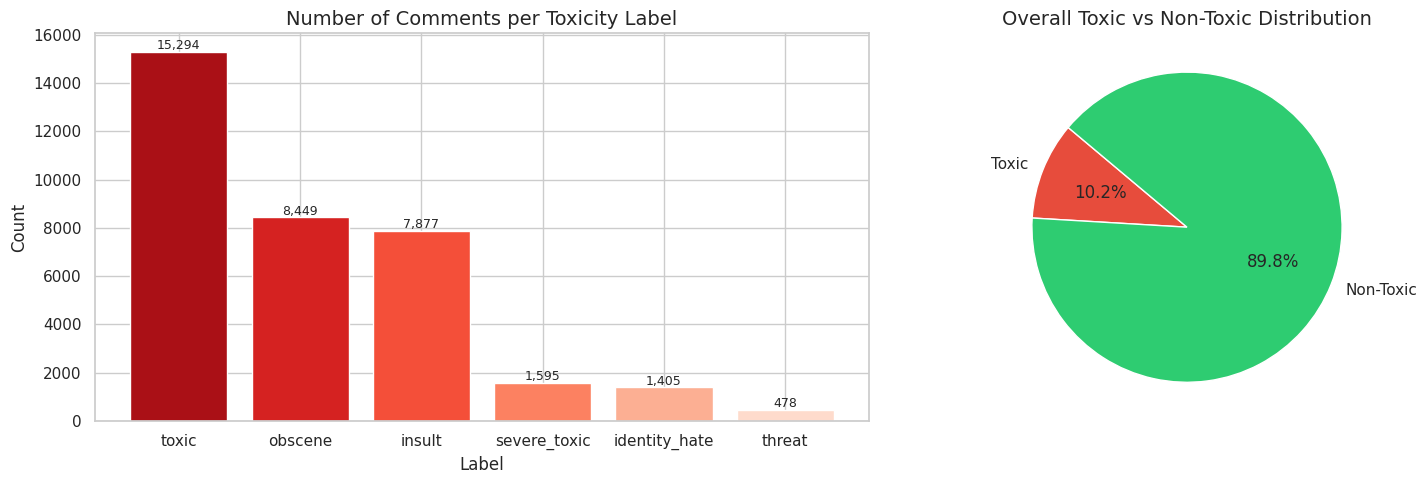

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Co-occurrence heatmap

Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

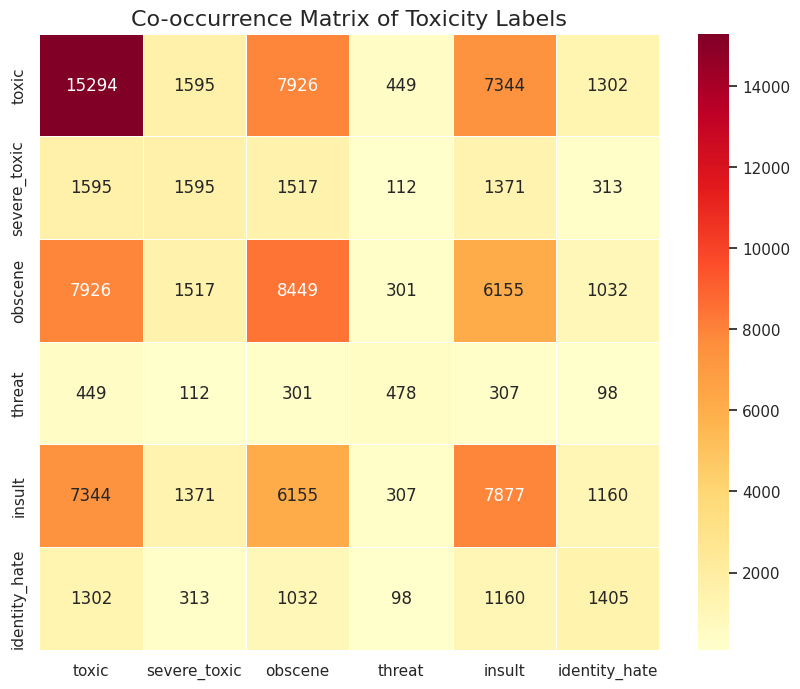

In [12]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.4 Word clouds

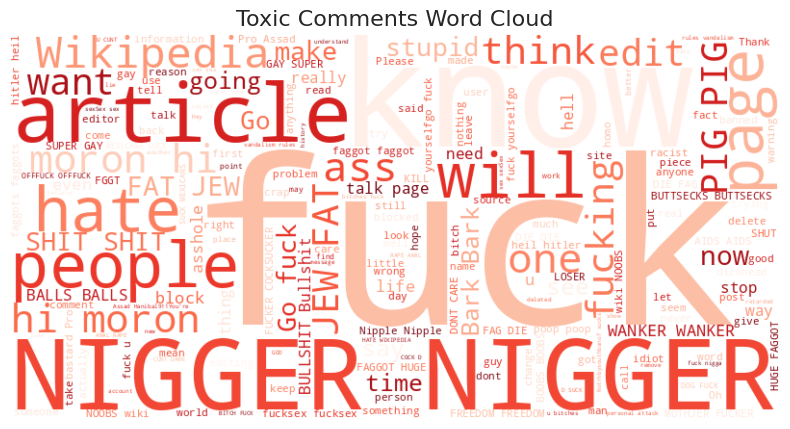

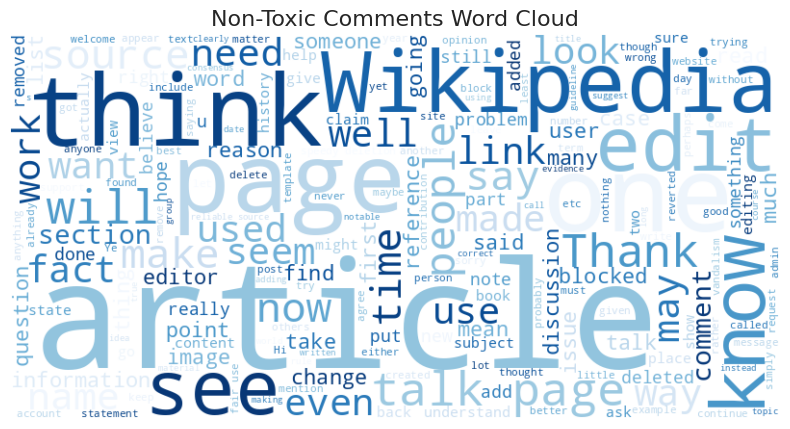

In [13]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

## 3.5 Top n-grams

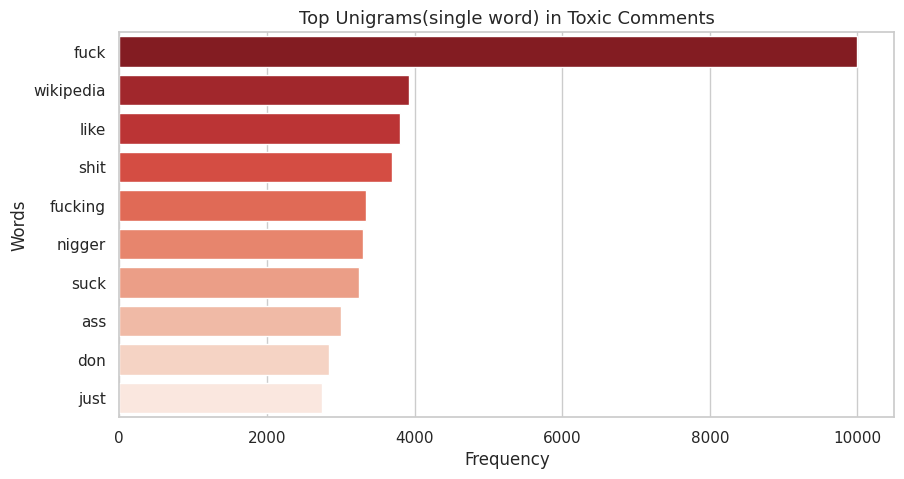

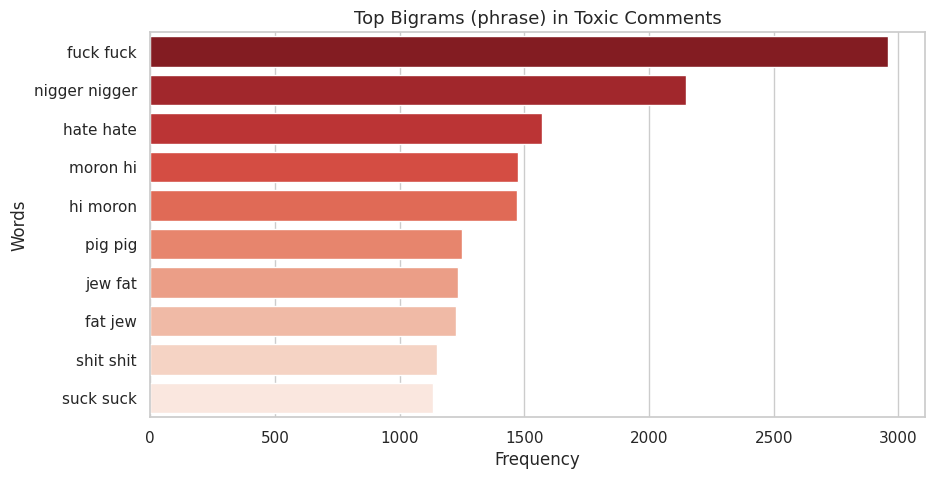

In [14]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# 4. Preprocessing

## 4.1 Basic preprocessing



1.  Lower case



In [15]:
def to_lower(text):
    return text.lower()




2. URL remove



In [16]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)

3. Mentions remove




In [17]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)

4. Remove Punctuation

In [18]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)

5. Remove extra space

In [19]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

## 4.2 Advance Preprocessing

1. Emoji to text

In [20]:
!pip install emoji
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 25.0 MB/s eta 0:00:00


2. Convert to full forms

In [21]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [22]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4.Bad Word Normalization \
b!tch = bitch

In [23]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [24]:
def tokenize_text(text):
    return word_tokenize(text)

6. Stopwords

In [25]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [26]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

7. Lemmatize

In [27]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

## 4.3 Final pipelines



1.   Basic Preprocess Function



In [28]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text



2.  Advanced Preprocess Function



In [29]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# 5. Apply Preprocessing



## 1. Applying Basic Preprocess Function






In [30]:
train_df["raw"] = train_df["comment_text"]
train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)

Comparison Of Raw and Basic Clean by Basic Preprocessing

In [31]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
126240,I suggest this for deletion since the article for B&H; Airlines already has this information,i suggest this for deletion since the article for bh airlines already has this information
103910,""", you've nailed it. In fact, that looks an awful lot like the edit we collaborated on earlier today. In fairness to Malke and in the interest of consensus, we should search for a one-sentence quote from Carender that really gets to the core of WHY. It would seem a little unbalanced if we didn't at least have *a* quote. Thoughts? \n\n""",youve nailed it in fact that looks an awful lot like the edit we collaborated on earlier today in fairness to malke and in the interest of consensus we should search for a onesentence quote from carender that really gets to the core of why it would seem a little unbalanced if we didnt at least have a quote thoughts
138631,"Emure\nEmure is a city in Nigeria, it is in the Ekiti State, it is not the Ekiti State so stop changing it to the Ekiti State.",emure emure is a city in nigeria it is in the ekiti state it is not the ekiti state so stop changing it to the ekiti state
89209,"YOU ARE AN AWFUL STINKY PERSON, do not delete my stuff",you are an awful stinky person do not delete my stuff
96606,"""\n\nFurther I do belive we have Ignore All. So if my making a point to improve someones understanding of why something is included in an entry is somehow void of that general Concept well then I guess we all are SOL aren't we because sometimes the space requirements must be overlooked for the content. Now he is the one that had to go make a smug comment on that concept, Smug in my translation of his comment because of his history of making smug and unwelcome comments, durring heated debate of many members he has made unwelcome comments to degrade the idea, opinions and thoughts of others. Now as I understand thing a certain amount of friction is required by this site, due to the NPOV concept and Friction between members often brings a less bias entry, however his unwelcome comments bring the debates off of the topic and more to his """"translation"""" of """"rules"""" that even by wikipedia standards can be ignored in many circumstances. If you want proof of his additude go to his talk page and see where I forgot to sign a post, he could not just make a note on the side stating who posted, he had to make a dig and post the """"guideline"""" about it. kinda petty.... """,further i do belive we have ignore all so if my making a point to improve someones understanding of why something is included in an entry is somehow void of that general concept well then i guess we all are sol arent we because sometimes the space requirements must be overlooked for the content now he is the one that had to go make a smug comment on that concept smug in my translation of his comment because of his history of making smug and unwelcome comments durring heated debate of many members he has made unwelcome comments to degrade the idea opinions and thoughts of others now as i understand thing a certain amount of friction is required by this site due to the npov concept and friction between members often brings a less bias entry however his unwelcome comments bring the debates off of the topic and more to his translation of rules that even by wikipedia standards can be ignored in many circumstances if you want proof of his additude go to his talk page and see where i forgot to sign a post he could not just make a note on the side stating who posted he had to make a dig and post the guideline about it kinda petty


## 2. Applying Advanced Preprocess Function

In [32]:
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [33]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)

Comparison of Raw and Advanced Clean by Advanced Preprocessing

In [34]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
98156,"December 28 Edits\nSean,",december edits sean
74733,"I think you are missing the point. I am 28 and an active member of the community. I do personally know lesbians. But whether its going out to dinner, or working at the Food Co-op, lesbians don't seem any more common than elsewhere in New York City. There is ONE lesbian bar on 4th Ave. \n\nPark Slope IS NOT called Dyke Slope by anyone except perhaps as an insult. You are missing the point. ITs a fiction!!!",think missing point active member community personally know lesbian whether going dinner working food coop lesbian seem common elsewhere new york city one lesbian bar th ave park slope called dyke slope anyone except perhaps insult missing point fiction
152002,"Stalker\n\nWhats your problem? Why the heck are you always stalking my posts and edits? If it makes you feel big pushing me and Aryan around like that then you better stop before I report it. And I was not in a edit war, I put it up for deletion after people in the talk page were discussing its deletion, Aryan kept getting rid of it.",stalker whats problem heck always stalking post edits make feel big pushing aryan around like better stop report edit war put deletion people talk page discussing deletion aryan kept getting rid
109958,"""\nCan anyone doubt that Arab refusal to recognize the Jewish state was the cause of the Six-Day War? Pre-war rhetoric was fill with blood-curdling chants of """"itbach al-yahud"""" or """"slaughter the Jews."""" This mantra was repeated over and over. Moreover, there was no """"occupation"""" before the Six-Day War. Yet the Arabs, led by Egypt, still called for """"throwing the Jews into the sea."""" So the question is why? why would they want to throw the Jews into the sea if there was no """"occupation."""" the reason stems from the fact that the source of the conflict has nothing to do with the so-called """"occupation"""" and everythingg to do the persistent Arab refusal to recognize a so-called """"foreign implant"""" or Western dhimmi presence in the """"plundered soil of Palestine."""" Therefore, this edit is accurate and adds balance. In truth, I'd rather see the entire sentence that precededs it, The status of the Israeli-occupied territories and the concurrent refugee problem, are central concerns in the ongoing Israeli–Palestinian conflict, raising issues in international law, and having far-reaching consequences in global affairs, removed per the concerns raised by Cptnono. Also, it constitutes WP:SYNTH. It is summary opinion that doesn't belong and it is not encyclopedic. So I propose that either my edit be allowed to remain or in the alternative, the entire aforementioned sentence be removed. """,anyone doubt arab refusal recognize jewish state cause sixday war prewar rhetoric fill bloodcurdling chant itbach alyahud slaughter jew mantra repeated moreover occupation sixday war yet arab led egypt still called throwing jew sea question would want throw jew sea occupation reason stem fact source conflict nothing socalled occupation everythingg persistent arab refusal recognize socalled foreign implant western dhimmi presence plundered soil palestine therefore edit accurate add balance truth id rather see entire sentence precededs status israelioccupied territory concurrent refugee problem central concern ongoing israelipalestinian conflict raising issue international law farreaching consequence global affair removed per concern raised cptnono also constitutes wpsynth summary opinion doesnt belong encyclopedic propose either edit allowed remain alternative entire aforementioned sentence removed
139514,Good luck. It doesn't seem to matter at Wikipedia how badly written an article is as long as there's some argument that the subject is notable.,good luck doesnt seem matter wikipedia badly written article long there argument subject notable


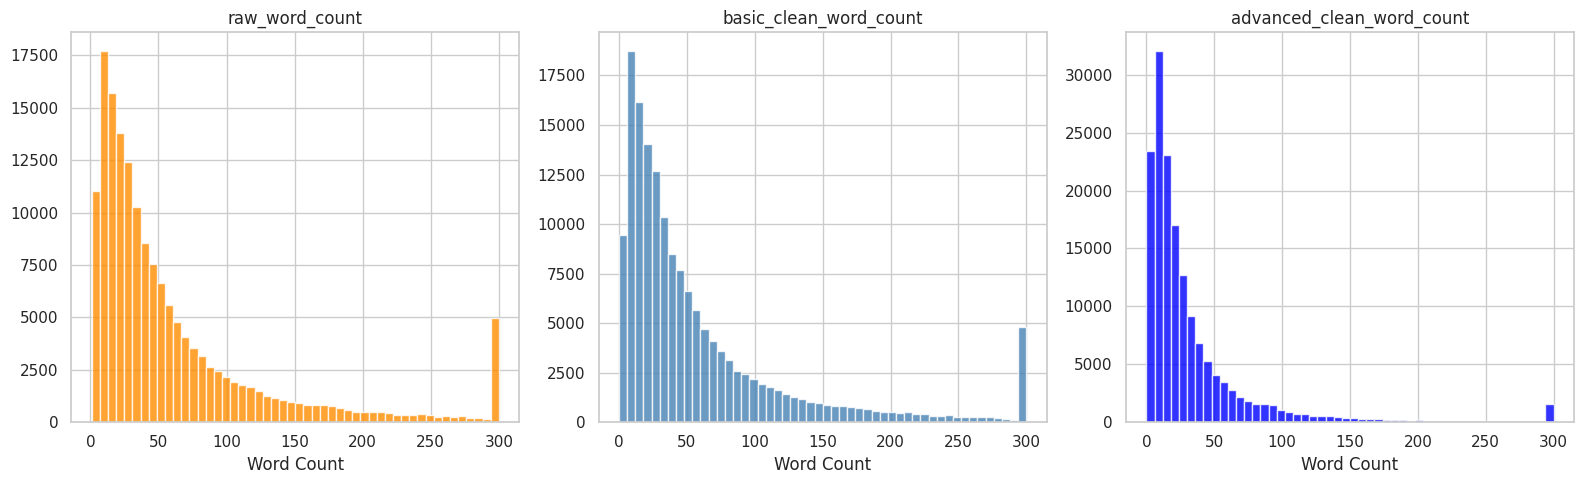

In [35]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


# 6. Train/Validation/Test Split

In [37]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')


Train : 127,656  |  Val : 15,957  |  Test : 15,958


# 7. Feature Extraction

## 7.1 TF-IDF Features

(for LR and SVM)
use advanced_clean

In [38]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])

In [39]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


## 7.2 LSTM Tokenization

In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [41]:
Vocab_size =10000
max_len= 100

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['basic_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts)
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['basic_clean'])
X_val_lstm = to_padded(X_val['basic_clean'])
X_test_lstm = to_padded(X_test['basic_clean'])

## 7.3 BERT Tokenization

In [89]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)
from torch.optim import AdamW

In [90]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

# 8 . Evaluation Utilities

## 1. evaluate()

In [44]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]

## 2. confusion matrix

In [45]:
def plot_confusion(model_name,y_true, y_pred, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), lables):
       cm = confusion_matrix(y_true[:, lables.index(col)],
                              y_pred[:, lables.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# 9. Traditional ML Models

## 9.1 Logistic Regression

Raw Text

In [46]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
with open('lr_raw_model.pkl', 'wb') as f:
    pickle.dump(lr_raw, f)
with open('tfidf_raw_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_raw, f)

In [47]:
with open('tfidf_raw_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('lr_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [48]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 18.5s


Evaluate the model for raw data

In [49]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 18.5s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 18.5,
 'infer time (s)': 0.0}

Confusion plot for the model for raw data

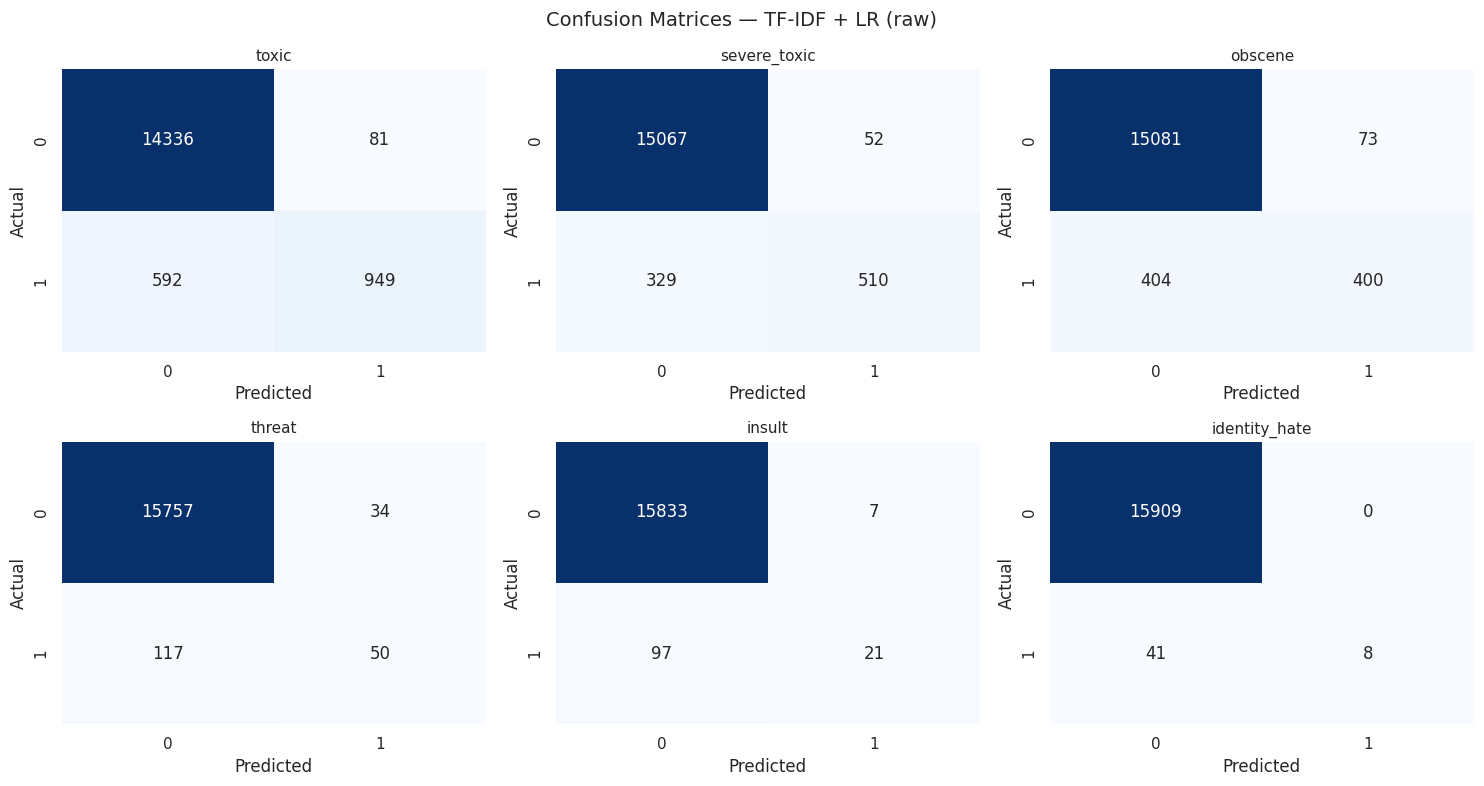

In [50]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

Advanced Clean

In [51]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
with open('lr_clean_model.pkl', 'wb') as f:
    pickle.dump(lr_clean, f)
with open('tfidf_clean_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_clean, f)

In [52]:
with open('tfidf_clean_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('lr_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [53]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 10.8s


Evaluate the model for clean data

In [54]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 10.8s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 10.8,
 'infer time (s)': 0.0}

Confusion plot for the model for clean data

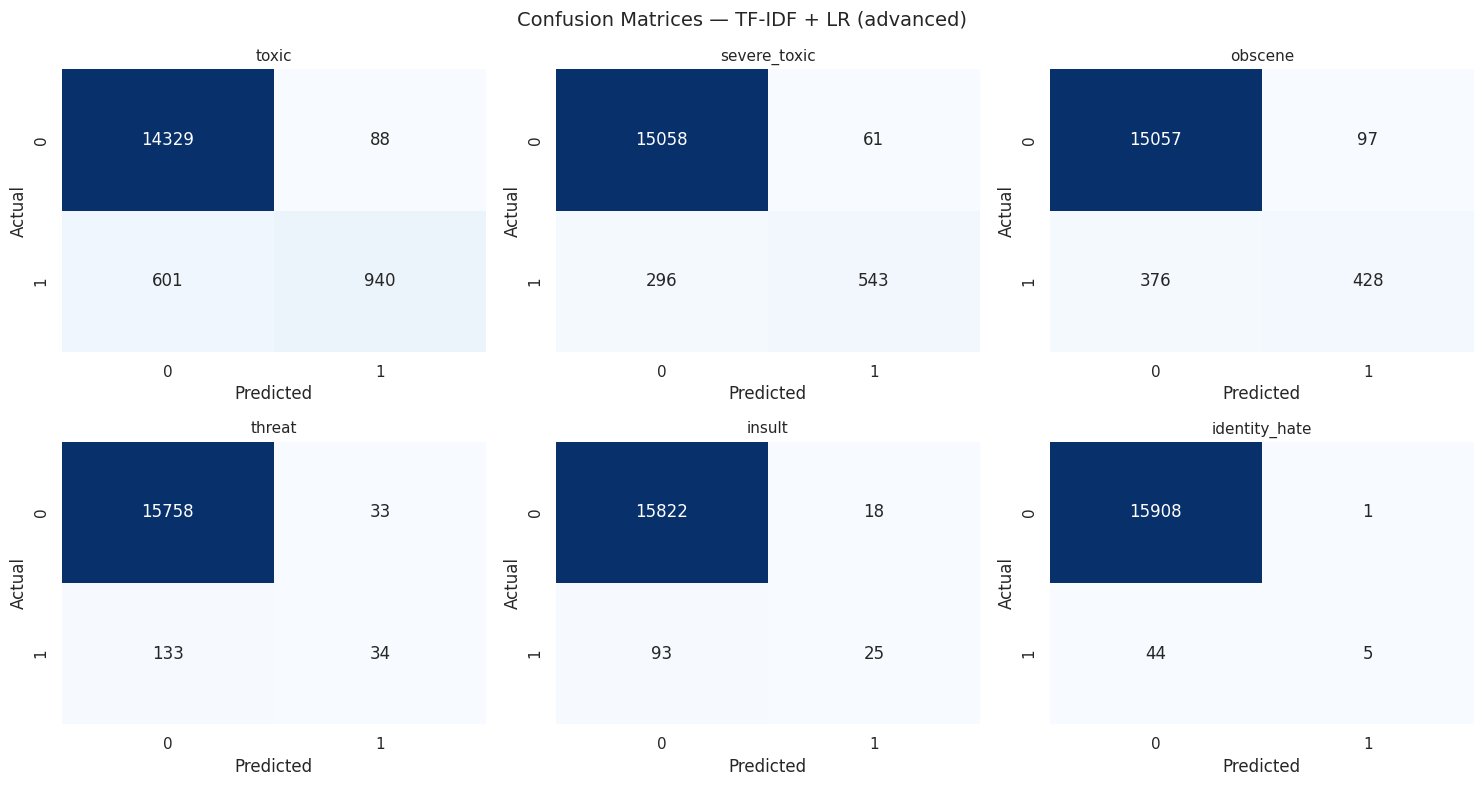

In [55]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

## 9.2 SVM

Raw Text

In [56]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
with open('svm_raw_model.pkl', 'wb') as f:
    pickle.dump(svm_raw, f)

In [57]:
with open('svm_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [58]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 11.4s


Evaluate the model for raw data

In [59]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 11.4s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 11.4,
 'infer time (s)': 0.0}

Confusion plot for the model for raw data

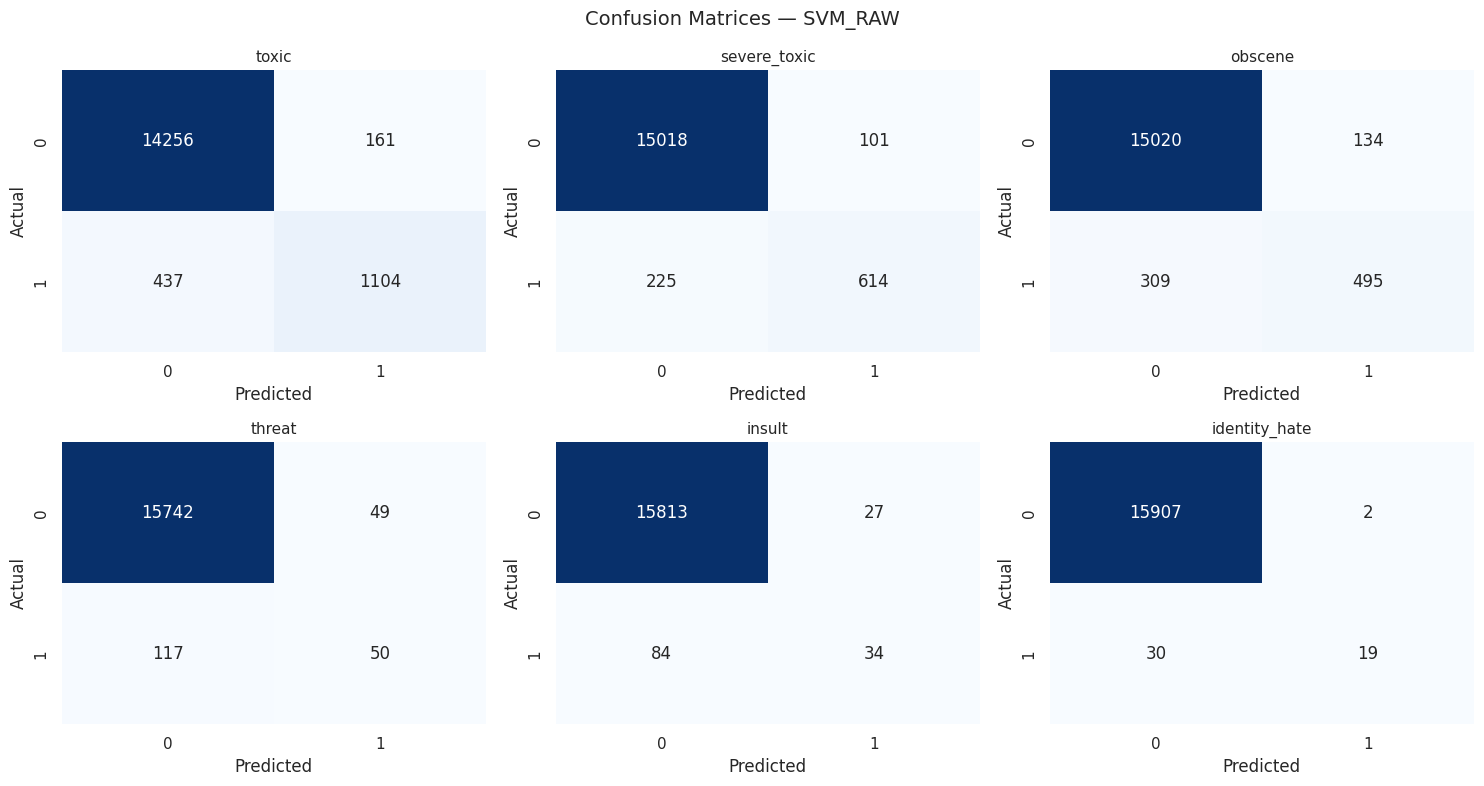

In [60]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

Advanced Clean

In [61]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
with open('svm_clean_model.pkl', 'wb') as f:
    pickle.dump(svm_clean, f)

In [62]:
with open('svm_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [63]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 6.3s



Evaluate the model for clean data

In [64]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 6.3s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 6.3,
 'infer time (s)': 0.0}

Confusion plot for the model for clean data

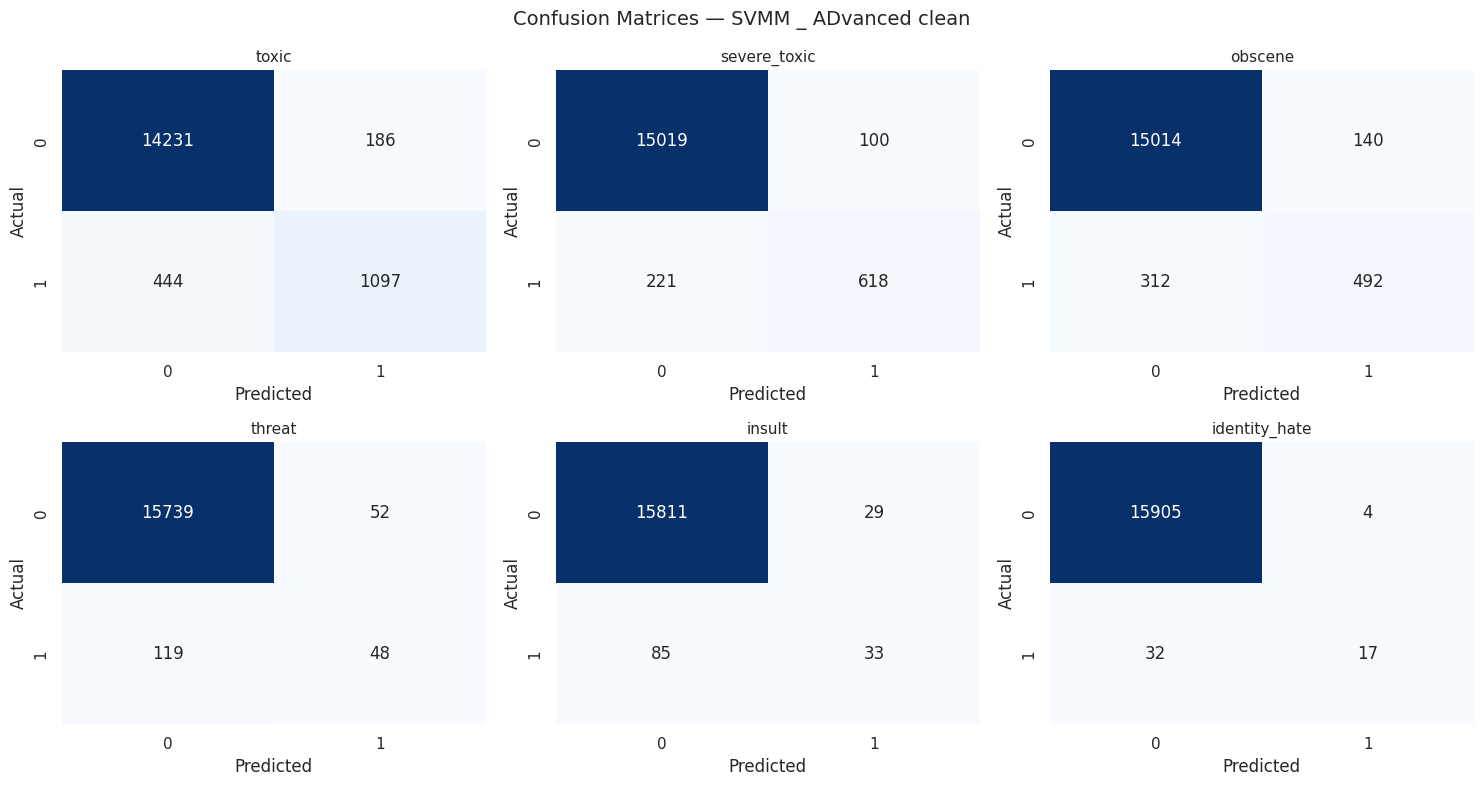

In [65]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

# 10. Deep Learning Model

## 10.1 BiLSTM — Basic Clean

Building the model

In [66]:
EMBED_DIM = 128
NUM_LABELS = len(label_cols)

def build_bilstm(Vocab_size, max_len, num_labels):
    inp  = Input(shape=(max_len,))
    x    = Embedding(Vocab_size, EMBED_DIM)(inp)
    x    = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
    x    = GlobalMaxPooling1D()(x)
    x    = Dense(128, activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(num_labels, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model
lstm_model = build_bilstm(Vocab_size , max_len, NUM_LABELS)
lstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396,102 (5.33 MB)

 Trainable params: 1,396,102 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [67]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Basic clean

In [68]:
callbacks =[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
            ]
t0=time.time()
history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_val_lstm, y_val.values),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
lstm_model.save("bilstm_model.h5")

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.8650 - loss: 0.0813 - val_accuracy: 0.9927 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9601 - loss: 0.0487 - val_accuracy: 0.9927 - val_loss: 0.0499 - learning_rate: 0.0010
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9545 - loss: 0.0447 - val_accuracy: 0.9927 - val_loss: 0.0509 - learning_rate: 0.0010
Epoch 4/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9532 - loss: 0.0422
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9442 - loss: 0.0411 - val_accuracy: 0.9924 - val_loss: 0.0520 - learning_rate: 0.0010
Epoch 5/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.9199 - loss: 0.0361 - val_accuracy: 0.9910 - val_loss: 0.0559 - learning_rate: 5.0000e-04


In [69]:
from tensorflow.keras.models import load_model
loaded_lstm = load_model("bilstm_model.h5")

In [70]:
train_t = time.time() - t0

print(f'Train time: {train_t:.1f}s')
t0 = time.time()
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
lstm_infer_t = time.time() - t0

Train time: 90.9s
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [71]:
evaluate('LSTM — Basic Clean', y_test.values, y_pred_lstm,
         train_t, lstm_infer_t)


===== LSTM — Basic Clean =====
  accuracy : 0.9187
  precision: 0.4813
  recall   : 0.4325
  f1 Macro : 0.4463
  train time: 90.9s


{'accuracy': 0.9187,
 'precision': 0.4813,
 'recall': 0.4325,
 'f1 (macro)': 0.4463,
 'train time (s)': 90.9,
 'infer time (s)': 5.2}

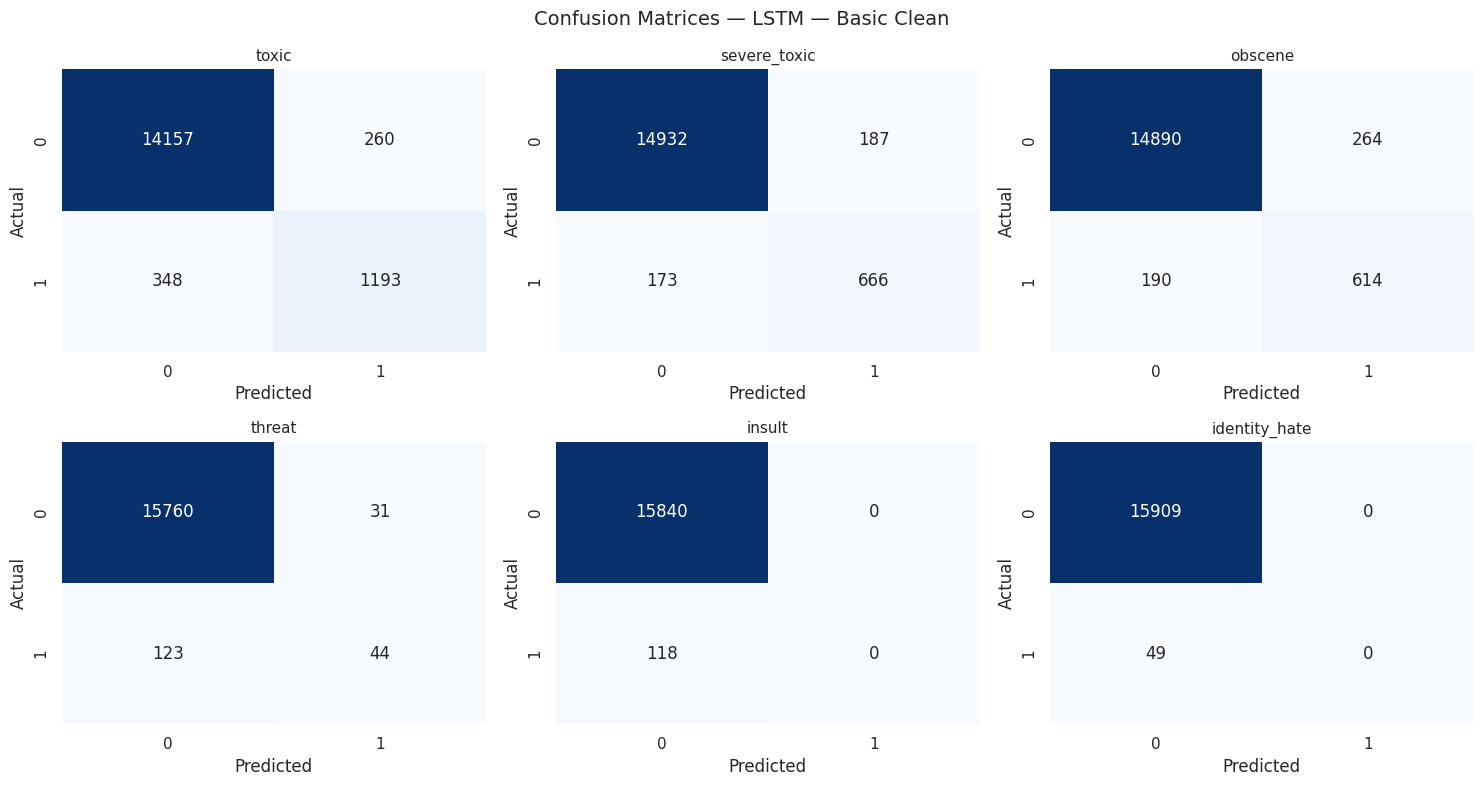

In [72]:
plot_confusion('LSTM — Basic Clean', y_test.values, y_pred_lstm,label_cols)

## Raw DATA

In [73]:
lstm_tok_raw = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok_raw.fit_on_texts(X_train['raw'])

def to_padded_raw(texts):
    seqs = lstm_tok_raw.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen= max_len ,padding='post', truncating='post')

X_train_lstm_raw = to_padded_raw(X_train['raw'])
X_val_lstm_raw   = to_padded_raw(X_val['raw'])
X_test_lstm_raw  = to_padded_raw(X_test['raw'])

lstm_raw_model = build_bilstm(Vocab_size, max_len, NUM_LABELS)

t0 = time.time()
lstm_raw_model.fit(
    X_train_lstm_raw, y_train.values,
    validation_data=(X_val_lstm_raw, y_val.values),
    epochs=10, batch_size=256,
    callbacks=callbacks, verbose=1
)
lstm_model.save("lstm_raw_model.h5")

Epoch 1/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.8463 - loss: 0.0974 - val_accuracy: 0.9927 - val_loss: 0.0517 - learning_rate: 0.0010
Epoch 2/10
498/499 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9734 - loss: 0.0511
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9739 - loss: 0.0496 - val_accuracy: 0.9927 - val_loss: 0.0504 - learning_rate: 0.0010
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9706 - loss: 0.0450 - val_accuracy: 0.9927 - val_loss: 0.0507 - learning_rate: 5.0000e-04


In [74]:
loaded_lstm = load_model("lstm_raw_model.h5")

In [75]:
lstm_raw_train_time = time.time() - t0

t0 = time.time()
y_pred_lstm_raw = (lstm_raw_model.predict(X_test_lstm_raw) > 0.5).astype(int)
lstm_raw_infer = time.time() - t0

499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [76]:
evaluate('LSTM — Raw', y_test.values, y_pred_lstm_raw, lstm_raw_train_time, lstm_raw_infer)


===== LSTM — Raw =====
  accuracy : 0.9189
  precision: 0.4895
  recall   : 0.3934
  f1 Macro : 0.4165
  train time: 36.9s


{'accuracy': 0.9189,
 'precision': 0.4895,
 'recall': 0.3934,
 'f1 (macro)': 0.4165,
 'train time (s)': 36.9,
 'infer time (s)': 2.9}

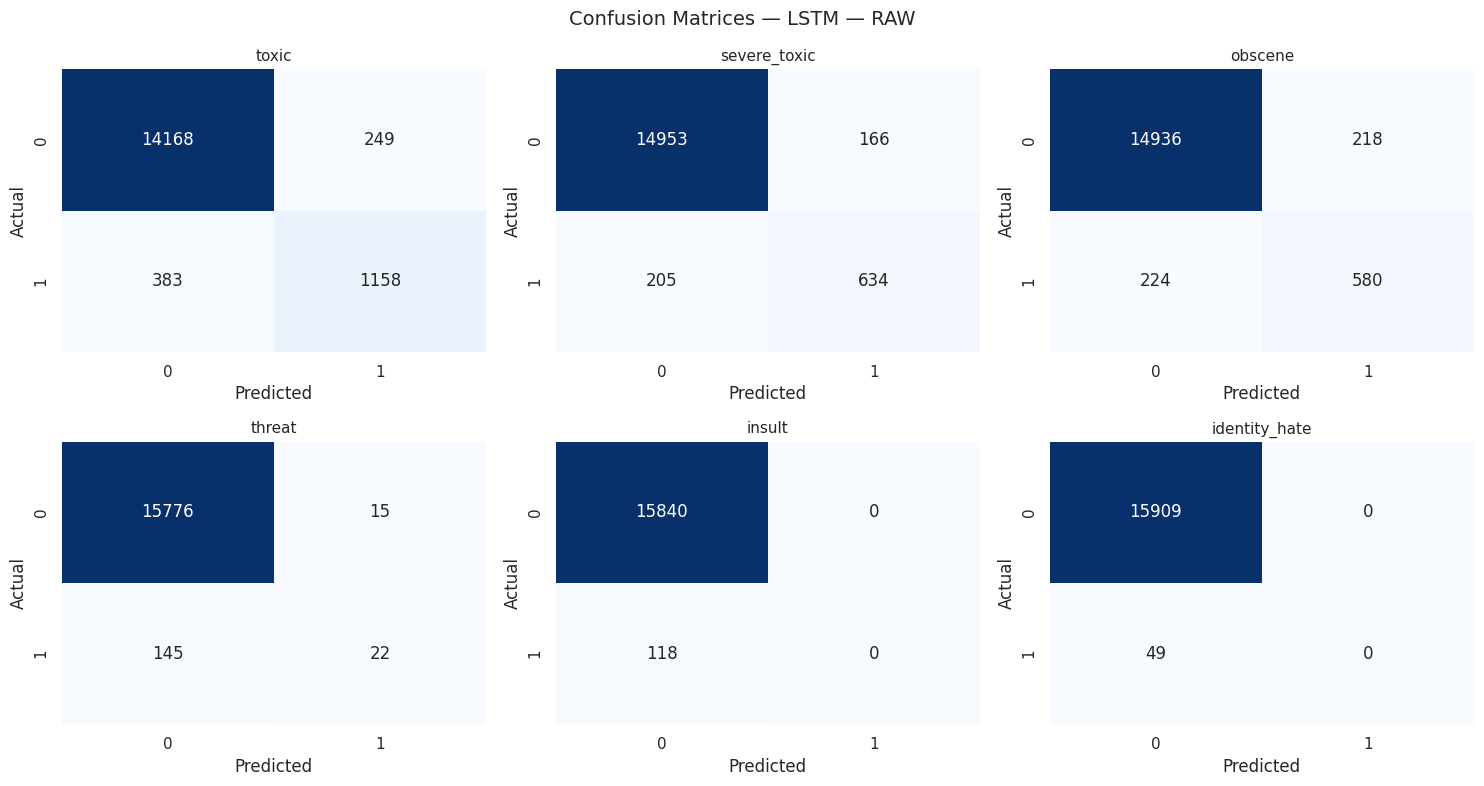

In [77]:
plot_confusion('LSTM — RAW', y_test.values, y_pred_lstm_raw,label_cols)

Plot training curves

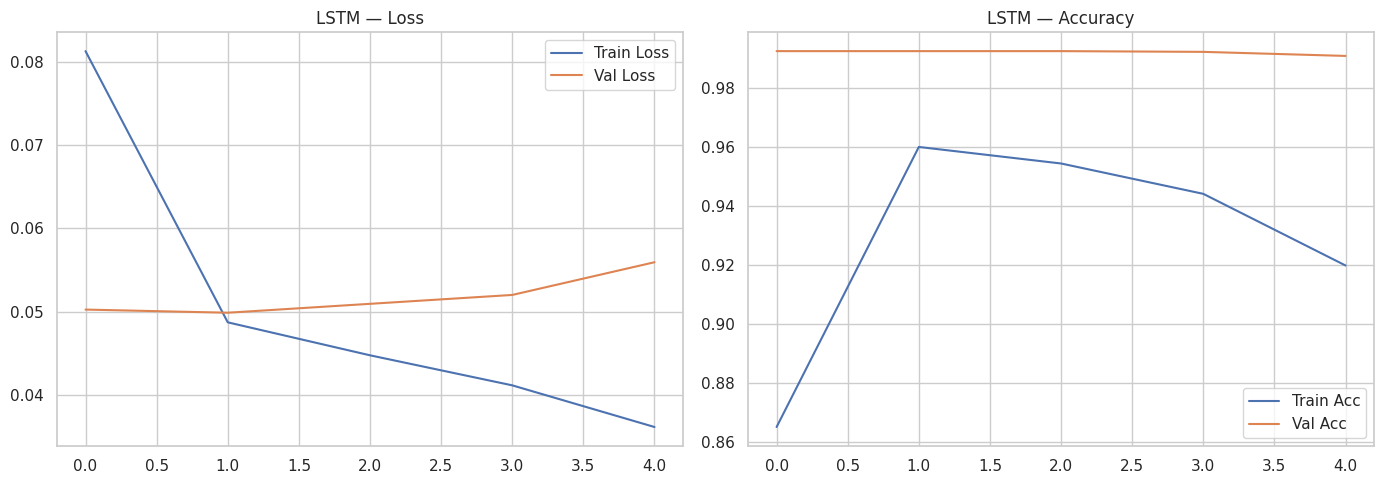

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. Transformer Model

##  BERT Fine-tuning

11.1 dataset class

In [91]:
from torch.utils.data import Dataset, DataLoader

In [92]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Dataset
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.float)
        }

Device: cuda


In [93]:
# Hyperparameters
BERT_BATCH = 32
BERT_EPOCHS = 1
BERT_MAX_LEN = 48

# Create datasets
train_ds = ToxicDataset(X_train['raw'].tolist(), y_train.values, Bert_tokenizer, BERT_MAX_LEN)
val_ds   = ToxicDataset(X_val['raw'].tolist(), y_val.values, Bert_tokenizer, BERT_MAX_LEN)
test_ds  = ToxicDataset(X_test['raw'].tolist(), y_test.values, Bert_tokenizer, BERT_MAX_LEN)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BERT_BATCH)
test_loader  = DataLoader(test_ds, batch_size=BERT_BATCH)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 3990
Val batches: 499


11.2 Load the model

In [94]:
bert_model = BertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification'
).to(DEVICE)


loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/config.json
You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Model config BertConfig {
  "activation": "gelu",
  "add_cross_attention": false,
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dim": 3072,
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
  

Loading weights: 0it [00:00, ?it/s]

BertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.weight   | UNEXPECTED | 
distilbert.embeddings.word_embeddings.weight                             | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2,

In [95]:
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * BERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = torch.nn.BCEWithLogitsLoss()

print("BERT model ready.")

BERT model ready.


11.3 Training

In [96]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):

        for batch in loader:

            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = criterion(outputs.logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )

                optimizer.step()
                scheduler.step()

            total_loss += loss.item()

            preds = (
                torch.sigmoid(outputs.logits) > 0.5
            ).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        np.vstack(all_preds),
        np.vstack(all_labels)
    )

11.3 training loop

In [97]:
best_val_loss = float('inf')

bert_train_losses = []
bert_val_losses = []

for epoch in range(BERT_EPOCHS):

    start = time.time()

    train_loss, _, _ = run_epoch(
        bert_model,
        train_loader,
        train=True
    )

    val_loss, val_preds, val_labels = run_epoch(
        bert_model,
        val_loader,
        train=False
    )

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average='macro',
        zero_division=0
    )

    elapsed = time.time() - start

    print(
        f'Epoch {epoch+1}/{BERT_EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val F1: {val_f1:.4f} | '
        f'Time: {elapsed:.0f}s'
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            bert_model.state_dict(),
            'best_bert.pt'
        )

Epoch 1/1 | Train Loss: 0.0768 | Val Loss: 0.0550 | Val F1: 0.4372 | Time: 1215s


11.4 evaluation

In [102]:
bert_model.load_state_dict(torch.load('best_bert.pt'))

t0 = time.time()
test_loss, y_pred_bert, y_true_bert = run_epoch(
    bert_model,
    test_loader,
    train=False
)
bert_infer_t = time.time() - t0

In [103]:
evaluate('BERT — Raw', y_true_bert, y_pred_bert, elapsed, bert_infer_t)


===== BERT — Raw =====
  accuracy : 0.9157
  precision: 0.4815
  recall   : 0.4338
  f1 Macro : 0.4536
  train time: 1214.5s


{'accuracy': 0.9157,
 'precision': 0.4815,
 'recall': 0.4338,
 'f1 (macro)': 0.4536,
 'train time (s)': 1214.5,
 'infer time (s)': 64.3}

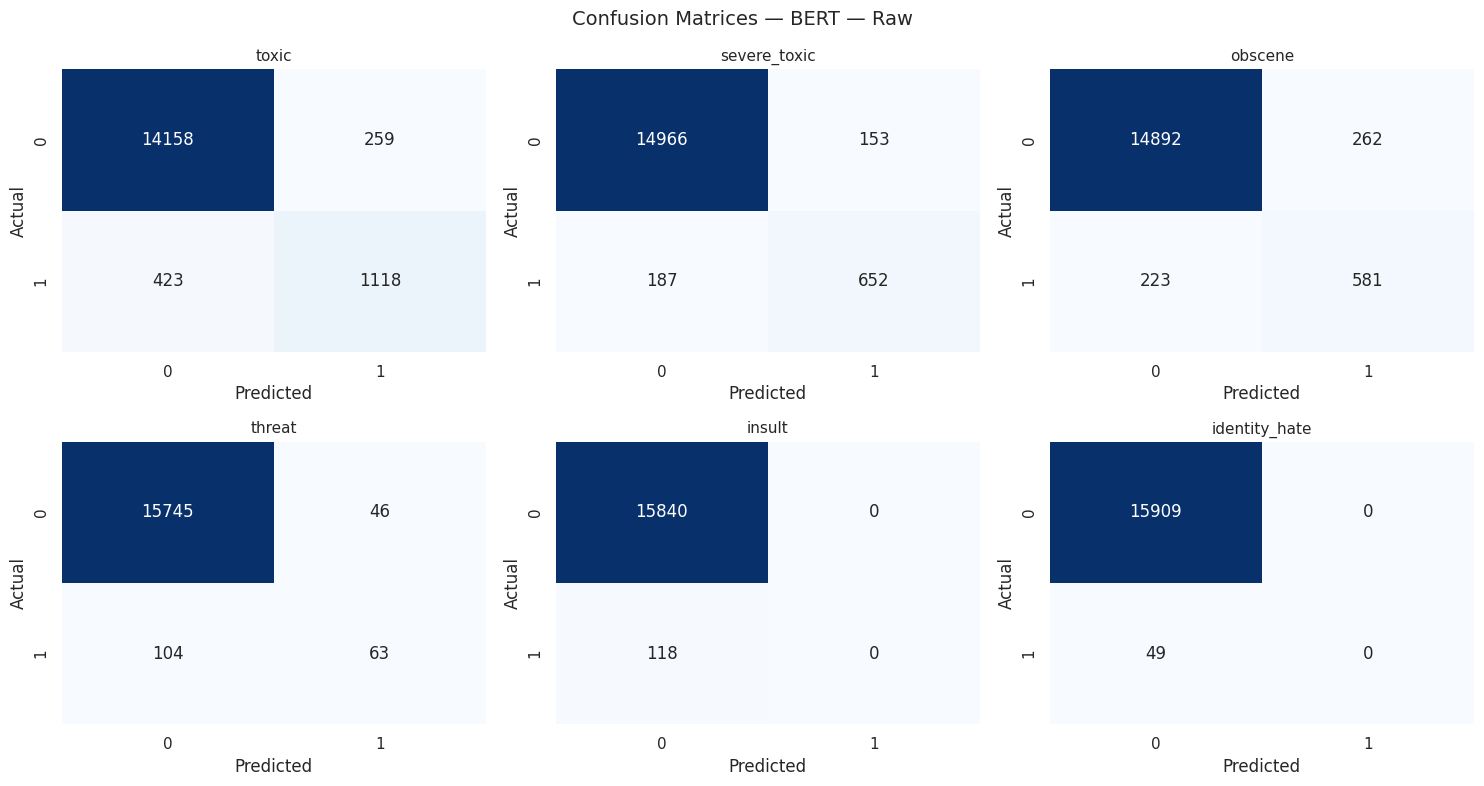

In [104]:
plot_confusion('BERT — Raw', y_true_bert, y_pred_bert)

# 12. Comparative Analysis


## 12.1 performance comparison

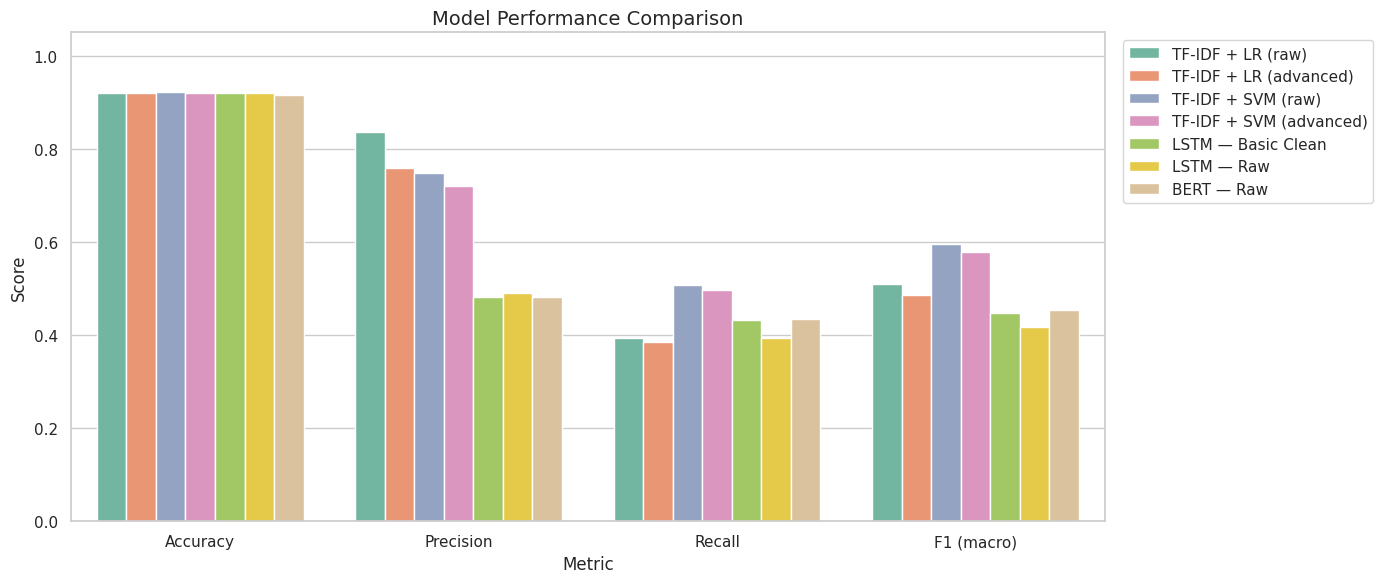

In [105]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1 (macro)']

results_df = pd.DataFrame.from_dict(results, orient='index').reset_index().rename(columns={'index': 'Model'})
plot_df = results_df[['Model'] + metric_cols].copy()
plot_df[metric_cols] = plot_df[metric_cols].astype(float)

plot_melted = plot_df.melt(id_vars='Model', value_vars=metric_cols,
                           var_name='Metric', value_name='Score')

display_name_map = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1 (macro)': 'F1 (macro)'
}
plot_melted['Metric'] = plot_melted['Metric'].map(display_name_map)


plt.figure(figsize=(14, 6))
sns.barplot(data=plot_melted, x='Metric', y='Score', hue='Model',
            palette='Set2')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.2 preprocessing impact

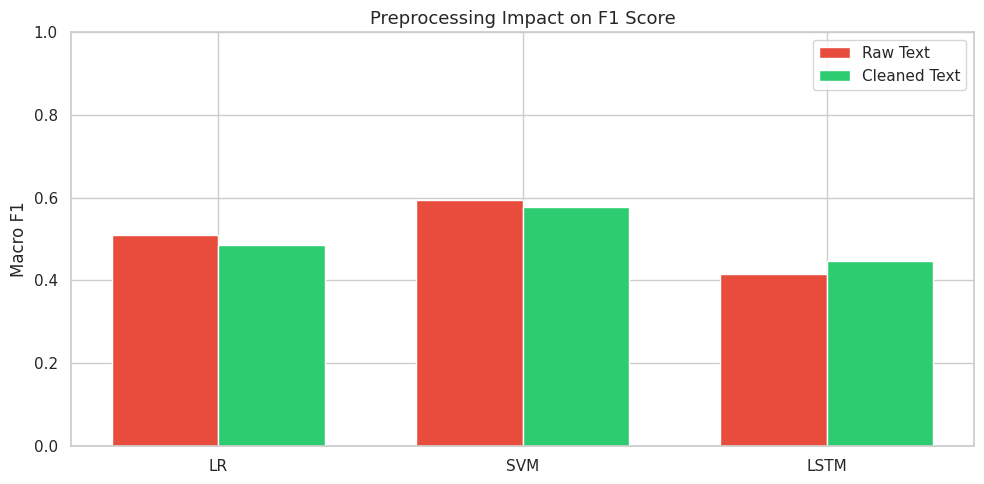

  Architecture  F1 Raw  F1 Cleaned
0           LR  0.5099      0.4852
1          SVM  0.5944      0.5780
2         LSTM  0.4165      0.4463


In [106]:
raw_models = [m for m in results if 'raw' in m.lower()]

clean_models = [
    m for m in results
    if 'clean' in m.lower() or 'advanced' in m.lower()
]

preprocess_rows = []
for arch in ['LR','SVM','LSTM']:
    raw_key   = next((m for m in raw_models   if arch.lower() in m.lower()), None)
    clean_key = next((m for m in clean_models if arch.lower() in m.lower()), None)
    if raw_key and clean_key:
        preprocess_rows.append({
            'Architecture': arch,
            'F1 Raw'      : results[raw_key]['f1 (macro)'],
            'F1 Cleaned'  : results[clean_key]['f1 (macro)']
        })

preproc_df = pd.DataFrame(preprocess_rows)

x = np.arange(len(preproc_df))
w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - w/2, preproc_df['F1 Raw'],     w, label='Raw Text',     color='#e74c3c')
ax.bar(x + w/2, preproc_df['F1 Cleaned'], w, label='Cleaned Text', color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels(preproc_df['Architecture'])
ax.set_title('Preprocessing Impact on F1 Score', fontsize=13)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('preprocessing_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(preproc_df)

## 12.3 training time

/tmp/ipykernel_10418/3521546180.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=time_df, x='Model', y='train time (s)', palette='Blues_d')


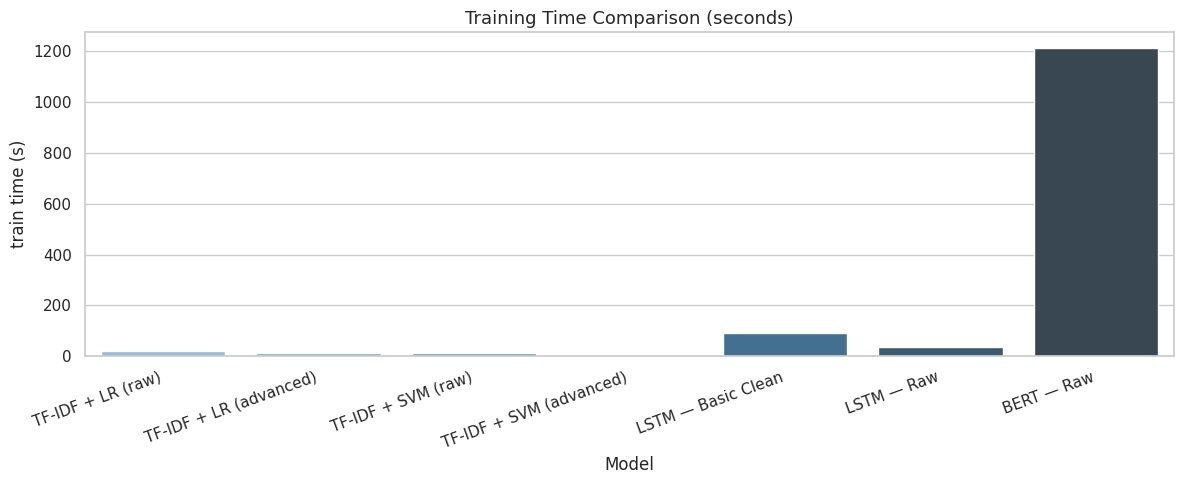

In [107]:
time_df = results_df[['Model', 'train time (s)']].copy()
time_df = time_df[time_df['train time (s)'] != '-']
time_df['train time (s)'] = time_df['train time (s)'].astype(float)

plt.figure(figsize=(12, 5))
sns.barplot(data=time_df, x='Model', y='train time (s)', palette='Blues_d')
plt.title('Training Time Comparison (seconds)', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.4 error analysis

In [108]:
test_texts = X_test['raw'].values

wrong_mask = (y_true_bert != y_pred_bert).any(axis=1)
wrong_idx  = np.where(wrong_mask)[0]

print(f'Misclassified samples (BERT): {wrong_mask.sum()} / {len(y_true_bert)}')

error_df = pd.DataFrame({
    'text'       : [test_texts[i][:200] for i in wrong_idx[:20]],
    'true_labels': [dict(zip(label_cols, y_true_bert[i])) for i in wrong_idx[:20]],
    'pred_labels': [dict(zip(label_cols, y_pred_bert[i])) for i in wrong_idx[:20]]
})

pd.set_option('display.max_colwidth', 120)
error_df.head(10)

Misclassified samples (BERT): 1345 / 15958


,text,true_labels,pred_labels
0,"""I think all of you americans you have a real attitude and mental problem !\nFirst you live in a World full of consp...","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
1,"""\n\n Swedish joke #1 \n\nSince self-righteous Mr.choppers knows nothing about the USDM D15B8 which he relentlessly ...","{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
2,And this meat puppet would be whom? Tim Foxworth,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
3,Holy Jesus crap \n\nYou just commited the worst sin possible & theres no redemtion so once you die you be going to h...,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': True, 'threat': False, 'insult': False, 'identity_hate': False}"
4,"It presumes that the dumbfucks who troll about the ending have any good reason to do so, so it is biased.","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
5,2011 French Open \n\nDon't leave silly little messages on my talk page saying I haven't explained myself and revert ...,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
6,"""\n\n Oh and as far as """"not in line at all with how things are done"""", that's pure horse shit and you know it. Disa...","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
7,dude wtf \n\nI was cleaning off some junk that slipped in when I copypasted my stuff so I could add a comment when s...,"{'toxic': 0.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
8,"By the way, are there any Azeris looking like this guy. Having lived among the Jews for a long time I can declare th...","{'toxic': 0.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
9,"Lying, scheming, vindictive Weasel \n\nBurn in hell.","{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"


#13. Final Discussion


In [109]:
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)
print(results_df.to_string(index=False))
print('='*70)

best_model = results_df.iloc[0]
print(f'\n Best model : {best_model["Model"]}')
print(f' F1 (macro) : {best_model["f1 (macro)"]}')
print(f' Accuracy   : {best_model["accuracy"]}')


FINAL RESULTS SUMMARY
                  Model  accuracy  precision  recall  f1 (macro)  train time (s)  infer time (s)
      TF-IDF + LR (raw)    0.9204     0.8366  0.3936      0.5099            18.5             0.0
 TF-IDF + LR (advanced)    0.9189     0.7585  0.3845      0.4852            10.8             0.0
     TF-IDF + SVM (raw)    0.9209     0.7476  0.5065      0.5944            11.4             0.0
TF-IDF + SVM (advanced)    0.9187     0.7193  0.4957      0.5780             6.3             0.0
     LSTM — Basic Clean    0.9187     0.4813  0.4325      0.4463            90.9             5.2
             LSTM — Raw    0.9189     0.4895  0.3934      0.4165            36.9             2.9
             BERT — Raw    0.9157     0.4815  0.4338      0.4536          1214.5            64.3

 Best model : TF-IDF + LR (raw)
 F1 (macro) : 0.5099
 Accuracy   : 0.9204
